In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [56]:
# Load training and testing datasets

train_df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")
test_df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training data shape: (64374, 12)
Testing data shape: (41315, 12)

Training columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Testing columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [57]:
print("===== TRAINING FILE =====")
display(train_df.head())

print("\nTraining data information:")
train_df.info()

print("\nChurn distribution:")
print(train_df["Churn"].value_counts())

print("\n===== TESTING FILE =====")
display(test_df.head())

print("\nTesting data information:")
test_df.info()

print("\nChurn distribution:")
print(test_df["Churn"].value_counts())

===== TRAINING FILE =====


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0



Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB

Churn distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

===== TESTING FILE =====


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0



Testing data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41315 entries, 0 to 41314
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         41315 non-null  int64  
 1   Age                41315 non-null  int64  
 2   Gender             41315 non-null  object 
 3   Tenure             41315 non-null  int64  
 4   Usage Frequency    41315 non-null  int64  
 5   Support Calls      41315 non-null  int64  
 6   Payment Delay      41315 non-null  int64  
 7   Subscription Type  41314 non-null  object 
 8   Contract Length    41314 non-null  object 
 9   Total Spend        41314 non-null  float64
 10  Last Interaction   41314 non-null  float64
 11  Churn              41314 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 3.8+ MB

Churn distribution:
Churn
1.0    39986
0.0     1328
Name: count, dtype: int64


In [58]:
# Check missing values in both datasets

print("Training missing values:")
print(train_df.isnull().sum())

print("\nTesting missing values:")
print(test_df.isnull().sum())

print("\nTotal missing values:")
print("Training:", train_df.isnull().sum().sum())
print("Testing:", test_df.isnull().sum().sum())

Training missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Testing missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Total missing values:
Training: 0
Testing: 5


In [59]:
# Remove completely empty rows from the testing dataset

test_df = test_df.dropna(how="all").reset_index(drop=True)

print("Testing data shape after removing empty row:", test_df.shape)

print("\nMissing values after cleaning:")
print(test_df.isnull().sum().sum())

Testing data shape after removing empty row: (41315, 12)

Missing values after cleaning:
5


In [60]:
# Check duplicate Customer IDs

print("Training duplicate CustomerIDs:",
      train_df["CustomerID"].duplicated().sum())

print("Testing duplicate CustomerIDs:",
      test_df["CustomerID"].duplicated().sum())

print("\nTraining duplicate rows:",
      train_df.duplicated().sum())

print("Testing duplicate rows:",
      test_df.duplicated().sum())

Training duplicate CustomerIDs: 0
Testing duplicate CustomerIDs: 0

Training duplicate rows: 0
Testing duplicate rows: 0


In [61]:
# Check data types

print("Data types:")
print(train_df.dtypes)

print("\nUnique values in categorical columns:")

for column in ["Gender", "Subscription Type", "Contract Length"]:
    print(f"\n{column}:")
    print(train_df[column].unique())

Data types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

Unique values in categorical columns:

Gender:
['Female' 'Male']

Subscription Type:
['Basic' 'Standard' 'Premium']

Contract Length:
['Monthly' 'Annual' 'Quarterly']


In [62]:
# Churn distribution

print("Churn distribution:")
print(train_df["Churn"].value_counts())

print("\nChurn percentage:")
print(train_df["Churn"].value_counts(normalize=True) * 100)

Churn distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Churn percentage:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


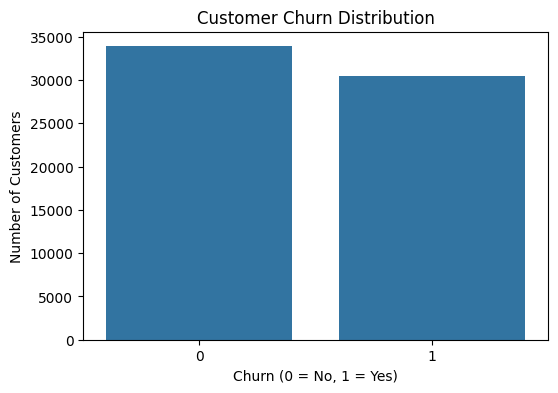

In [63]:
# Visualize churn distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
# Churn by subscription type

churn_subscription = pd.crosstab(
    train_df["Subscription Type"],
    train_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by subscription type:")
display(churn_subscription)

Churn percentage by subscription type:


Churn,0,1
Subscription Type,,
Basic,51.722530,48.277470
Premium,53.503571,46.496429
Standard,52.669519,47.330481


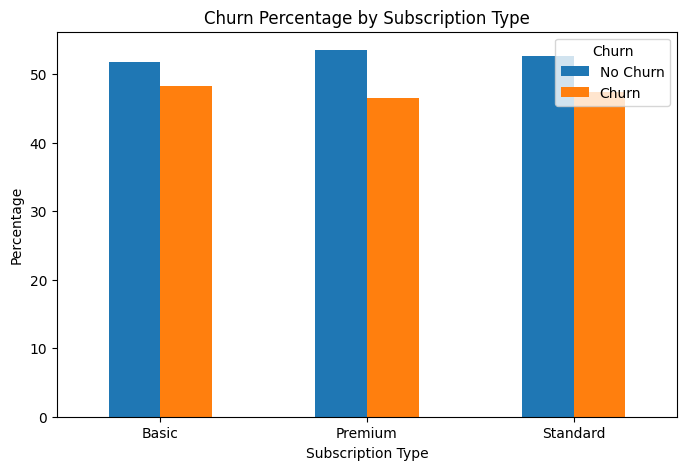

In [65]:
# Visualize churn by subscription type

churn_subscription.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn", labels=["No Churn", "Churn"])

plt.show()

In [66]:
# Churn percentage by contract length

churn_contract = pd.crosstab(
    train_df["Contract Length"],
    train_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract length:")
display(churn_contract)

Churn percentage by contract length:


Churn,0,1
Contract Length,,
Annual,53.783279,46.216721
Monthly,48.391324,51.608676
Quarterly,55.951810,44.048190


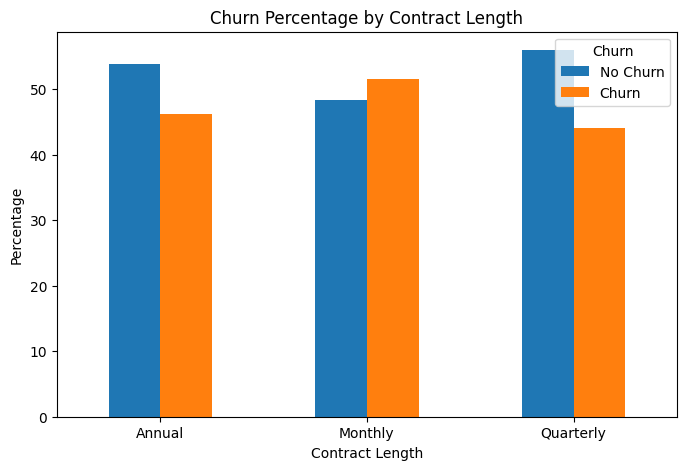

In [67]:
# Visualize churn by contract length

churn_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn", labels=["No Churn", "Churn"])

plt.show()

In [68]:
# Average support calls by churn status

support_churn = train_df.groupby("Churn")["Support Calls"].mean()

print("Average Support Calls by Churn Status:")
print(support_churn)

Average Support Calls by Churn Status:
Churn
0    4.500753
1    6.400617
Name: Support Calls, dtype: float64


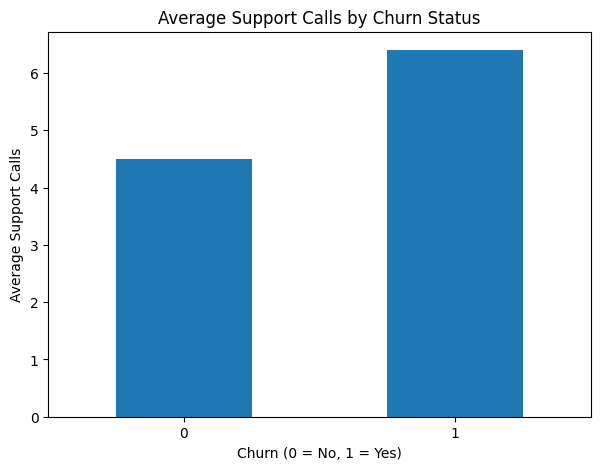

In [69]:
# Visualize average support calls by churn status

plt.figure(figsize=(7, 5))

support_churn.plot(kind="bar")

plt.title("Average Support Calls by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Support Calls")
plt.xticks(rotation=0)

plt.show()

In [70]:
# Average payment delay by churn status

payment_delay_churn = train_df.groupby("Churn")["Payment Delay"].mean()

print("Average Payment Delay by Churn Status:")
print(payment_delay_churn)

Average Payment Delay by Churn Status:
Churn
0    12.453086
1    22.334897
Name: Payment Delay, dtype: float64


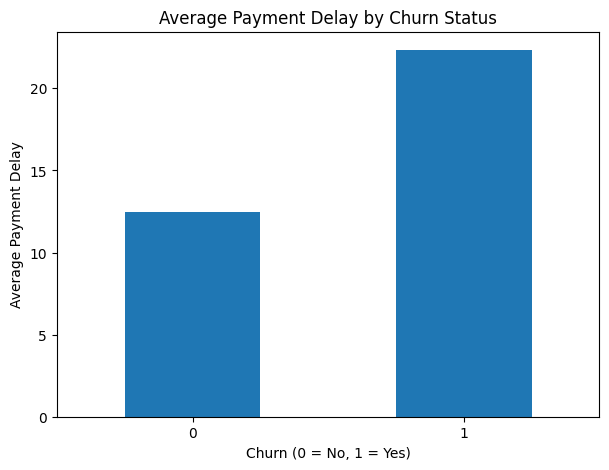

In [71]:
# Visualize average payment delay by churn status

plt.figure(figsize=(7, 5))

payment_delay_churn.plot(kind="bar")

plt.title("Average Payment Delay by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Payment Delay")
plt.xticks(rotation=0)

plt.show()

In [72]:
# Average total spend by churn status

spend_churn = train_df.groupby("Churn")["Total Spend"].mean()

print("Average Total Spend by Churn Status:")
print(spend_churn)

Average Total Spend by Churn Status:
Churn
0    560.541956
1    519.336143
Name: Total Spend, dtype: float64


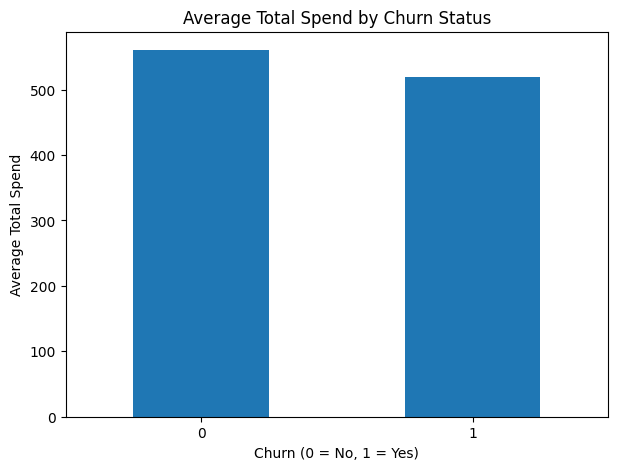

In [73]:
# Visualize average total spend by churn status

plt.figure(figsize=(7, 5))

spend_churn.plot(kind="bar")

plt.title("Average Total Spend by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Total Spend")
plt.xticks(rotation=0)

plt.show()

In [74]:
# Average age by churn status

age_churn = train_df.groupby("Churn")["Age"].mean()

print("Average Age by Churn Status:")
print(age_churn)

Average Age by Churn Status:
Churn
0    41.132700
1    42.902404
Name: Age, dtype: float64


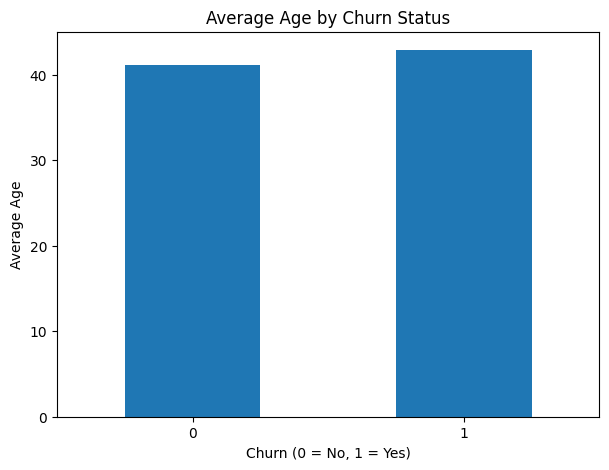

In [75]:
# Visualize average age by churn status

plt.figure(figsize=(7, 5))

age_churn.plot(kind="bar")

plt.title("Average Age by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Age")
plt.xticks(rotation=0)

plt.show()

In [76]:
# Churn percentage by gender

churn_gender = pd.crosstab(
    train_df["Gender"],
    train_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by gender:")
display(churn_gender)

Churn percentage by gender:


Churn,0,1
Gender,,
Female,44.950950,55.049050
Male,61.420339,38.579661


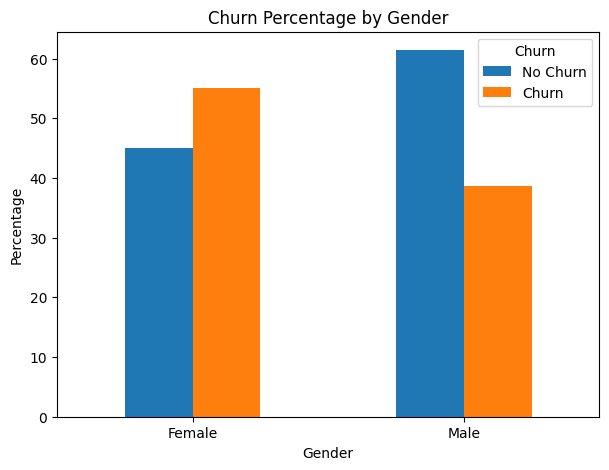

In [77]:
# Visualize churn percentage by gender

churn_gender.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn", labels=["No Churn", "Churn"])

plt.show()

In [78]:
# Average tenure by churn status

tenure_churn = train_df.groupby("Churn")["Tenure"].mean()

print("Average Tenure by Churn Status:")
print(tenure_churn)

Average Tenure by Churn Status:
Churn
0    28.826481
1    35.515200
Name: Tenure, dtype: float64


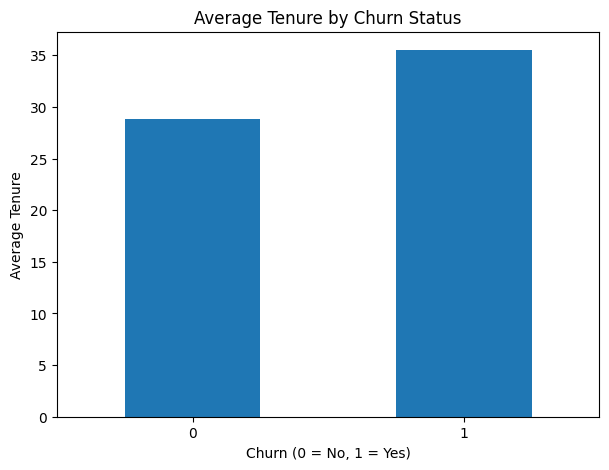

In [79]:
# Visualize average tenure by churn status

plt.figure(figsize=(7, 5))

tenure_churn.plot(kind="bar")

plt.title("Average Tenure by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Tenure")
plt.xticks(rotation=0)

plt.show()

In [80]:
# Average usage frequency by churn status

usage_churn = train_df.groupby("Churn")["Usage Frequency"].mean()

print("Average Usage Frequency by Churn Status:")
print(usage_churn)

Average Usage Frequency by Churn Status:
Churn
0    16.042915
1    14.010593
Name: Usage Frequency, dtype: float64


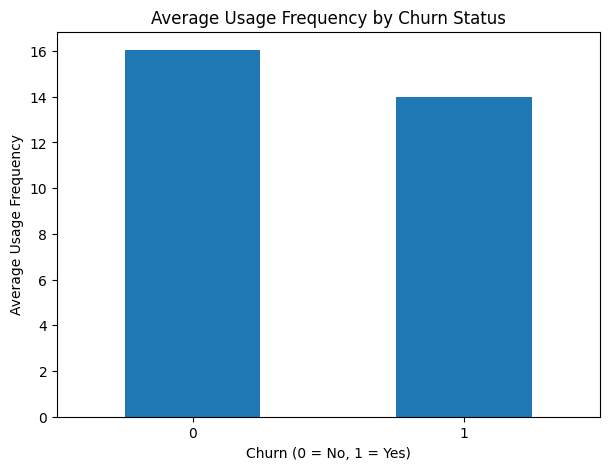

In [81]:
# Visualize average usage frequency by churn status

plt.figure(figsize=(7, 5))

usage_churn.plot(kind="bar")

plt.title("Average Usage Frequency by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Usage Frequency")
plt.xticks(rotation=0)

plt.show()

In [82]:
# Average last interaction by churn status

interaction_churn = train_df.groupby("Churn")["Last Interaction"].mean()

print("Average Last Interaction by Churn Status:")
print(interaction_churn)

Average Last Interaction by Churn Status:
Churn
0    15.521944
1    15.473191
Name: Last Interaction, dtype: float64


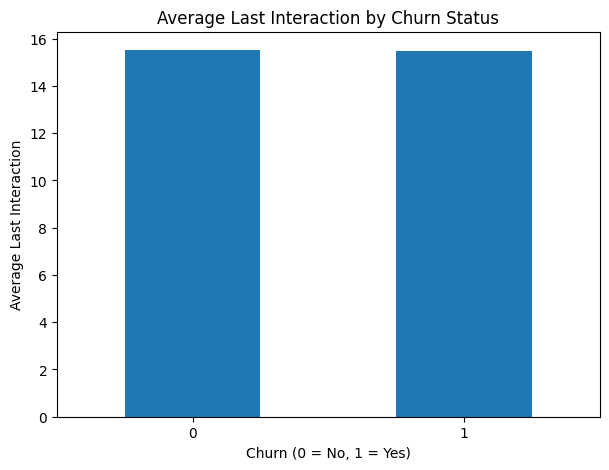

In [83]:
# Visualize average last interaction by churn status

plt.figure(figsize=(7, 5))

interaction_churn.plot(kind="bar")

plt.title("Average Last Interaction by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Last Interaction")
plt.xticks(rotation=0)

plt.show()

In [84]:
# Correlation of numerical features with Churn

numeric_columns = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    "Churn"
]

correlation = train_df[numeric_columns].corr()["Churn"].sort_values(
    ascending=False
)

print("Correlation with Churn:")
display(correlation)

Correlation with Churn:


,Churn
Churn,1.000000
Payment Delay,0.557386
Support Calls,0.304631
Tenure,0.195327
Age,0.063457
Last Interaction,-0.002818
Total Spend,-0.078867
Usage Frequency,-0.115098


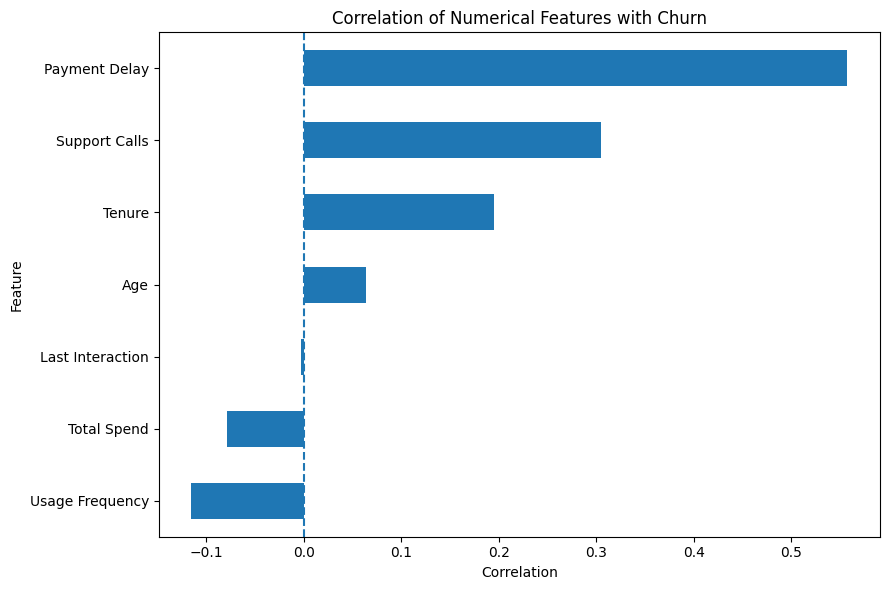

In [85]:
# Visualize correlation of numerical features with Churn

correlation_features = correlation.drop("Churn").sort_values()

plt.figure(figsize=(9, 6))

correlation_features.plot(kind="barh")

plt.title("Correlation of Numerical Features with Churn")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.axvline(x=0, linestyle="--")

plt.tight_layout()
plt.show()

In [86]:
# Prepare features and target variable

X = train_df.drop(columns=["Churn", "CustomerID"])
y = train_df["Churn"]

X_test = test_df.drop(columns=["Churn", "CustomerID"])
y_test = test_df["Churn"]

print("Training features shape:", X.shape)
print("Training target shape:", y.shape)
print("Testing features shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Training features shape: (64374, 10)
Training target shape: (64374,)
Testing features shape: (41315, 10)
Testing target shape: (41315,)

Categorical columns:
['Gender', 'Subscription Type', 'Contract Length']

Numerical columns:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

# Fit on training data and transform both datasets
X_train_encoded = preprocessor.fit_transform(X)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (64374, 15)
Encoded testing shape: (41315, 15)


In [88]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_encoded, y)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [89]:
# Check for missing values in encoded test data

print("Total NaN values in X_test_encoded:",
      np.isnan(X_test_encoded).sum())

print("NaN values by column:")

nan_counts = pd.DataFrame(
    X_test_encoded,
    columns=preprocessor.get_feature_names_out()
).isna().sum()

print(nan_counts[nan_counts > 0])

Total NaN values in X_test_encoded: 2
NaN values by column:
numerical__Total Spend         1
numerical__Last Interaction    1
dtype: int64


In [90]:
# Fix the 2 missing values in test data

X_test_clean = X_test.copy()

# Fill missing values using training dataframe medians
X_test_clean['Total Spend'] = X_test_clean['Total Spend'].fillna(
    train_df['Total Spend'].median()
)

X_test_clean['Last Interaction'] = X_test_clean['Last Interaction'].fillna(
    train_df['Last Interaction'].median()
)

# Check missing values
print("Total missing values in cleaned test data:",
      X_test_clean.isnull().sum().sum())

# Encode using the existing preprocessor
X_test_encoded = preprocessor.transform(X_test_clean)

print("Encoded testing shape:", X_test_encoded.shape)

# Final NaN check
print("Total NaN values in encoded test data:",
      np.isnan(X_test_encoded).sum())

Total missing values in cleaned test data: 2
Encoded testing shape: (41315, 15)
Total NaN values in encoded test data: 0


In [91]:
print("X_test shape:", X_test.shape)
print("X_test_clean shape:", X_test_clean.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_test shape: (41315, 10)
X_test_clean shape: (41315, 10)
X_test_encoded shape: (41315, 15)


In [92]:
# Find all train/test variables and their shapes

variables = list(globals().items())

for name, value in variables:
    if 'test' in name.lower() or 'train' in name.lower():
        if hasattr(value, 'shape'):
            print(name, "->", value.shape)

train_df -> (64374, 12)
test_df -> (41315, 12)
X_test -> (41315, 10)
y_test -> (41315,)
X_train_encoded -> (64374, 15)
X_test_encoded -> (41315, 15)
X_test_clean -> (41315, 10)


In [93]:
# Verify the datasets after correcting the file paths

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

print("\nTraining missing values:", train_df.isnull().sum().sum())
print("Testing missing values:", test_df.isnull().sum().sum())

Training data shape: (64374, 12)
Testing data shape: (41315, 12)

Training missing values: 0
Testing missing values: 5


In [94]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.lower().endswith('.csv'):
            print(os.path.join(root, file))

/content/customer_churn_dataset-testing-master.csv
/content/customer_churn_dataset-training-master.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv


In [95]:
# Reload the ORIGINAL datasets
# This resets train_df and test_df to the CSV files

train_df = pd.read_csv(
    "/content/customer_churn_dataset-training-master.csv"
)

test_df = pd.read_csv(
    "/content/customer_churn_dataset-testing-master.csv"
)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

print("\nTraining missing values:", train_df.isnull().sum().sum())
print("Testing missing values:", test_df.isnull().sum().sum())

Training data shape: (82397, 12)
Testing data shape: (64374, 12)

Training missing values: 9
Testing missing values: 0


In [96]:
print("TRAINING-MASTER FILE")
print(train_df.head())
print("\nColumns:")
print(train_df.columns.tolist())
print("\nChurn:")
print(train_df["Churn"].value_counts(dropna=False))

print("\n" + "="*60)

print("TESTING-MASTER FILE")
print(test_df.head())
print("\nColumns:")
print(test_df.columns.tolist())
print("\nChurn:")
print(test_df["Churn"].value_counts(dropna=False))

TRAINING-MASTER FILE
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           2   30  Female    39.0             14.0            5.0   
1           3   65  Female    49.0              1.0           10.0   
2           4   55  Female    14.0              4.0            6.0   
3           5   58    Male    38.0             21.0            7.0   
4           6   23    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4         

In [97]:
# Load the two actual datasets using clear names

model_train_df = pd.read_csv(
    "/content/customer_churn_dataset-testing-master.csv"
)

final_test_df = pd.read_csv(
    "/content/customer_churn_dataset-training-master.csv"
)

print("Model training data shape:", model_train_df.shape)
print("Final test data shape:", final_test_df.shape)

print("\nModel training missing values:")
print(model_train_df.isnull().sum())

print("\nFinal test missing values:")
print(final_test_df.isnull().sum())

Model training data shape: (64374, 12)
Final test data shape: (82397, 12)

Model training missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Final test missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [98]:
# Find rows containing missing values in the final test dataset

missing_rows = final_test_df[final_test_df.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))

print("\nRows containing missing values:")
display(missing_rows)

Number of rows with missing values: 1

Rows containing missing values:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
82396,84579,51,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
# Clean the final test dataset

# 1. Remove completely empty rows
final_test_df = final_test_df.dropna(how='all').copy()

# 2. Define numerical feature columns
numerical_columns = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

# 3. Fill missing numerical values using MEDIANS from model training data
for col in numerical_columns:
    final_test_df[col] = final_test_df[col].fillna(
        model_train_df[col].median()
    )

# 4. Check the result
print("Final test shape after cleaning:", final_test_df.shape)
print("Total missing values:", final_test_df.isnull().sum().sum())
print("\nMissing values by column:")
print(final_test_df.isnull().sum())

Final test shape after cleaning: (82397, 12)
Total missing values: 3

Missing values by column:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    1
Contract Length      1
Total Spend          0
Last Interaction     0
Churn                1
dtype: int64


In [100]:
# Prepare final test features for prediction

# Features used by the model
feature_columns = [
    'Age',
    'Gender',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Subscription Type',
    'Contract Length',
    'Total Spend',
    'Last Interaction'
]

# Create final test feature dataset
X_final_test = final_test_df[feature_columns].copy()

print("Final test features shape:", X_final_test.shape)
print("\nMissing values in final test features:")
print(X_final_test.isnull().sum())

Final test features shape: (82397, 10)

Missing values in final test features:
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    1
Contract Length      1
Total Spend          0
Last Interaction     0
dtype: int64


In [101]:
# Encode the final test features using the EXISTING preprocessor

X_final_test_encoded = preprocessor.transform(X_final_test)

print("Encoded final test shape:", X_final_test_encoded.shape)

# Check for NaN values
print("Total NaN values:", np.isnan(X_final_test_encoded).sum())

Encoded final test shape: (82397, 15)
Total NaN values: 0


In [102]:
# Generate final predictions using Logistic Regression

final_logistic_predictions = logistic_model.predict(X_final_test_encoded)

print("Final Logistic Regression predictions generated successfully!")
print("Number of predictions:", len(final_logistic_predictions))
print("First 10 predictions:", final_logistic_predictions[:10])

Final Logistic Regression predictions generated successfully!
Number of predictions: 82397
First 10 predictions: [0 1 1 0 0 1 0 1 0 0]


In [103]:
# Create final prediction dataframe

final_predictions_df = pd.DataFrame({
    'CustomerID': final_test_df['CustomerID'].astype(int),
    'Churn': final_logistic_predictions.astype(int)
})

# Save predictions to CSV
final_predictions_df.to_csv(
    '/content/final_customer_churn_predictions.csv',
    index=False
)

print("Final prediction file created successfully!")
print("Shape:", final_predictions_df.shape)

print("\nFirst 10 predictions:")
display(final_predictions_df.head(10))

print("\nChurn prediction distribution:")
print(final_predictions_df['Churn'].value_counts())

Final prediction file created successfully!
Shape: (82397, 2)

First 10 predictions:


,CustomerID,Churn
0,2,0
1,3,1
2,4,1
3,5,0
4,6,0
5,8,1
6,9,0
7,10,1
8,11,0
9,12,0



Churn prediction distribution:
Churn
0    53188
1    29209
Name: count, dtype: int64


In [104]:
# Final validation of prediction file

print("File saved successfully:")
print("/content/final_customer_churn_predictions.csv")

print("\nShape:")
print(final_predictions_df.shape)

print("\nColumn names:")
print(final_predictions_df.columns.tolist())

print("\nMissing values:")
print(final_predictions_df.isnull().sum())

print("\nDuplicate CustomerIDs:")
print(final_predictions_df['CustomerID'].duplicated().sum())

print("\nDuplicate rows:")
print(final_predictions_df.duplicated().sum())

File saved successfully:
/content/final_customer_churn_predictions.csv

Shape:
(82397, 2)

Column names:
['CustomerID', 'Churn']

Missing values:
CustomerID    0
Churn         0
dtype: int64

Duplicate CustomerIDs:
0

Duplicate rows:
0


In [105]:
import os

files = [
    "/content/customer_churn_dataset-training-master.csv",
    "/content/customer_churn_dataset-testing-master.csv",
    "/content/final_customer_churn_predictions.csv"
]

for file in files:
    print(file)
    print("Exists:", os.path.exists(file))
    if os.path.exists(file):
        print("Size:", os.path.getsize(file) / (1024 * 1024), "MB")
    print()

/content/customer_churn_dataset-training-master.csv
Exists: True
Size: 4.0 MB

/content/customer_churn_dataset-testing-master.csv
Exists: True
Size: 3.130168914794922 MB

/content/final_customer_churn_predictions.csv
Exists: True
Size: 0.6180877685546875 MB



In [106]:
import zipfile
from google.colab import files

files_to_download = [
    "/content/customer_churn_dataset-training-master.csv",
    "/content/customer_churn_dataset-testing-master.csv",
    "/content/final_customer_churn_predictions.csv"
]

zip_path = "/content/customer_churn_project_files.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_download:
        zipf.write(file_path, arcname=file_path.split("/")[-1])

print("ZIP created successfully!")
print("Location:", zip_path)

ZIP created successfully!
Location: /content/customer_churn_project_files.zip


In [107]:
from google.colab import files

files.download("/content/customer_churn_project_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>